<a href="https://colab.research.google.com/github/rijaleffendi2002-maker/tugas_gis/blob/main/Copy_of_Volume_Waduk_GIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 📝 Praktikum / Tugas

### Tugas 1 — Wajib (60% nilai)

**Deliverables:**
1. Tabel area–elevasi (interval 0.5 m) dalam format CSV & XLSX
2. Hitung volume pada elevasi: **95 m, 98 m, 100 m, 105 m** dengan **tiga metode**:
   - Trapezoidal dari tabel
   - Raster pixel-summation
   - Simpson / prismoidal
3. Kurva hypsometric (Area vs Elevasi, Volume vs Elevasi)
4. Peta kedalaman pada Normal Pool

### Tugas 2 — Bandingkan metode (25% nilai)
- Bandingkan hasil **Raster vs TIN** untuk DEM yang sama
- Diskusikan: mengapa berbeda? Kapan masing-masing lebih akurat?

### Tugas 3 — Analisis sensitivitas (15% nilai)
- Buat Monte Carlo dengan noise DEM σ = 1 m, 200 simulasi
- Laporkan mean, std, 95% CI dari volume
- Sketsa histogram & rekomendasi akurasi DEM untuk proyek nyata

### Format laporan:
- PDF maks. **5 halaman** + lampiran kode Python (script `.py` atau notebook `.ipynb`)
- Sitasi minimal **3 referensi** akademik
- Submit via LMS dengan nama file: `NIM_NamaLengkap_TugasWaduk.pdf`



## 📚 Referensi & Bacaan Lanjut

### Buku teks
1. **Linsley, Franzini, Freyberg, Tchobanoglous** — *Water Resources Engineering*, McGraw-Hill.
2. **Bras, R.L.** — *Hydrology: An Introduction to Hydrologic Science*, Addison-Wesley.
3. **Maidment, D.R. (ed.)** — *Handbook of Hydrology*, McGraw-Hill.
4. **Longley, Goodchild, Maguire, Rhind** — *Geographic Information Science and Systems*, Wiley.

### Manual / dokumentasi
- **QGIS User Manual** — bagian Raster Analysis, Hydrology.
- **ArcGIS Pro Documentation** — Spatial Analyst, 3D Analyst.
- **GDAL/OGR Cookbook** — https://gdal.org/
- **rasterio docs** — https://rasterio.readthedocs.io/

### Paper akademik (untuk metode lanjut)
- **Wang & Liu (2006)** — *An efficient method for identifying and filling surface depressions...* IJGIS.
- **Planchon & Darboux (2002)** — *A fast, simple and versatile algorithm to fill the depressions...* CATENA.
- **Hayashi & van der Kamp (2000)** — *Simple equations to represent the volume-area-depth relations...* J. Hydrology.
- **Cael & Seekell (2016)** — *The size-distribution of Earth's lakes*. Scientific Reports.

### Data sources Indonesia
- **DEMNAS / BIG** — https://tanahair.indonesia.go.id/demnas/
- **Inageoportal** — https://tanahair.indonesia.go.id/portal-web
- **Kementerian PUPR** — data bendungan & waduk



## 🎯 Ringkasan & Take-Home Messages

### Alur kerja kunci:

```
   DATA AKURAT  →  PREPROCESSING  →  TABEL AREA-ELEVASI
                                         ↓
                                    INTEGRASI VOLUME
                                  (trap/simpson/raster/TIN)
                                         ↓
                                    VERIFIKASI &
                                  ANALISIS SENSITIVITAS
                                         ↓
                                    OUTPUT: tabel +
                                    grafik + peta +
                                    laporan ketidakpastian
```

### 5 Hal yang Wajib Diingat:

1. **Reproyeksi ke UTM** sebelum menghitung area/volume.
2. **Bathymetri wajib** untuk waduk eksisting; DEM saja tidak cukup.
3. **Lebih dari satu metode** harus dipakai untuk cross-check.
4. **Δh ≤ 1 m** untuk integrasi yang akurat.
5. **Laporkan range/ketidakpastian**, bukan satu nilai absolut.

### Filosofi:
> *Volume waduk bukan sekedar angka — ia adalah fondasi keputusan untuk PLTA, irigasi, suplai air baku, dan pengendalian banjir. Sebuah error 5% pada volume bisa berarti perbedaan ratusan miliar rupiah pada nilai proyek.*

---

**Pertanyaan? — Diskusi terbuka!**  🙋‍♂️🙋‍♀️


**Reasoning**:
Mounting Google Drive is the first step to access files stored there.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


**Reasoning**:
Import the necessary libraries for geospatial operations, including `rasterio` for raster data, `geopandas` for vector data, and `numpy` for numerical operations.

In [2]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import pandas as pd
import pyproj

print("Required libraries imported successfully.")

Required libraries imported successfully.


## Load and Preprocess Real DEM Data

### Subtask:
Load the real DEMNAS data (GeoTIFF) and the provided SHP file. Reproject the DEM to a meter-based UTM coordinate system for accurate area and volume calculations. Clip the DEM using the SHP file to define your area of interest (e.g., the reservoir boundary or catchment area). This step will prepare your DEM for further analysis.

In [7]:
dem_path = '/content/drive/MyDrive/TUGAS GIS/DEMNAS_1209-24_v1.0 (1).tif'
shp_path = '/content/drive/MyDrive/TUGAS GIS/DANAU_AR_25K.shp' # Corrected path

# Load DEM
with rasterio.open(dem_path) as src:
    dem_original_crs = src.crs
    dem_original_transform = src.transform
    dem_original_meta = src.meta.copy()
    print(f"DEM loaded from: {dem_path}")
    print(f"DEM CRS: {src.crs}")
    print(f"DEM Bounds: {src.bounds}")
    print(f"DEM Shape: {src.shape}")
    print(f"DEM Resolution: {src.res}")

# Load SHP file
try:
    aoi_gdf = gpd.read_file(shp_path)
    print(f"\nSHP file loaded from: {shp_path}")
    print(f"SHP CRS: {aoi_gdf.crs}")
    print("SHP Head:")
    print(aoi_gdf.head())

    # The user has confirmed 'DANAU_AR_25K.shp' is the desired shapefile. If this shapefile
    # contains multiple features and only a specific lake ('DANAU') should be used for clipping,
    # you might need to filter `aoi_gdf` here. For example:
    # aoi_gdf = aoi_gdf[aoi_gdf['NAME_COLUMN'] == 'NAME_OF_YOUR_LAKE']

except Exception as e:
    print(f"Error loading SHP file from {shp_path}: {e}")
    print("Please ensure the SHP file exists at the specified path and is a valid shapefile.")

DEM loaded from: /content/drive/MyDrive/TUGAS GIS/DEMNAS_1209-24_v1.0 (1).tif
DEM CRS: EPSG:4326
DEM Bounds: BoundingBox(left=107.25, bottom=-6.75, right=107.5, top=-6.5)
DEM Shape: (3333, 3333)
DEM Resolution: (7.500750075007501e-05, 7.500750075007501e-05)

SHP file loaded from: /content/drive/MyDrive/TUGAS GIS/DANAU_AR_25K.shp
SHP CRS: EPSG:4326
SHP Head:
          NAMOBJ  OTODAN FCODE      REMARK KODLCO SRS_ID   LCODE METADATA  \
0   Waduk Cirata       0  None  Danau/Situ   None   None  DA0080     None   
1  Situ Wanayasa       0  None  Danau/Situ   None   None  DA0080     None   
2           None       0  None  Danau/Situ   None   None  DA0080     None   
3           None       0  None  Danau/Situ   None   None  DA0080     None   
4           None       0  None  Danau/Situ   None   None  DA0080     None   

   VOLTAP  DTA  ...  VLCSDN  QUAAR  CRH  KPTS  NAMWS NAMDAS LOKASI SHAPE_Leng  \
0     0.0  0.0  ...     0.0      0  0.0   0.0   None   None   None   1.495343   
1     0.0  0.0 

### Reproject DEM to UTM

It's crucial to reproject your DEM to a meter-based coordinate system (like UTM) for accurate area and volume calculations. This step ensures that measurements are in meters, not degrees. I'll use the `reproject_to_utm` function as defined in the notebook's workflow section.

In [4]:
def reproject_to_utm(src_path, dst_path, dst_crs=None):
    """Reprojects a raster to a specified UTM CRS."""
    with rasterio.open(src_path) as src:
        # Automatically determine UTM CRS if not provided
        if dst_crs is None:
            # Get centroid of the DEM and determine its UTM zone
            lon_center = (src.bounds.left + src.bounds.right) / 2
            lat_center = (src.bounds.bottom + src.bounds.top) / 2

            # Use pyproj to determine the UTM zone
            proj_in = pyproj.CRS(src.crs)
            if proj_in.is_geographic:
                transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True) # Web Mercator for general estimation
                x_web, y_web = transformer.transform(lon_center, lat_center)

                utm_zone = int(np.floor((lon_center + 180) / 6) + 1)
                is_north = "N" if lat_center >= 0 else "S"
                dst_crs = f"EPSG:326{utm_zone}" if is_north == "N" else f"EPSG:327{utm_zone}"
                print(f"Determined UTM CRS: {dst_crs}")
            else:
                print(f"Source CRS {src.crs} is already projected. No auto UTM conversion.")
                dst_crs = src.crs # Use source CRS if already projected


        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height,
            'nodata': src.nodata # Carry over nodata value
        })
        with rasterio.open(dst_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=transform, dst_crs=dst_crs,
                    resampling=Resampling.bilinear)
    print(f"DEM reprojected to {dst_path} with CRS {dst_crs}")

dem_reprojected_path = '/content/drive/MyDrive/TUGAS GIS/dem_reprojected.tif'
# You can specify dst_crs if you know it (e.g., 'EPSG:32749' for UTM Zone 49S)
# If None, it will try to determine the appropriate UTM zone based on the DEM's center.
reproject_to_utm(dem_path, dem_reprojected_path)


Determined UTM CRS: EPSG:32748
DEM reprojected to /content/drive/MyDrive/TUGAS GIS/dem_reprojected.tif with CRS EPSG:32748


### Clip DEM with Polygon

Now, we'll clip the reprojected DEM to your area of interest (the 'DANAU' feature from your SHP file). This will focus the analysis on the relevant region. I'll use the `clip_with_polygon` function as defined in the notebook's workflow section.

In [8]:
def clip_with_polygon(src_path, dst_path, aoi_gdf_to_clip):
    """Clips a raster using a GeoDataFrame polygon."""
    with rasterio.open(src_path) as src:
        # Ensure the AOI GeoDataFrame is in the same CRS as the source raster
        aoi_transformed = aoi_gdf_to_clip.to_crs(src.crs)

        # Mask the raster using the geometry from the AOI
        # If aoi_gdf has multiple polygons, mask will use all of them.
        out_image, out_transform = mask(src, aoi_transformed.geometry, crop=True, nodata=src.nodata)

        out_meta = src.meta.copy()
        out_meta.update({
            'height': out_image.shape[1],
            'width' : out_image.shape[2],
            'transform': out_transform,
            'nodata': src.nodata # Ensure nodata is explicitly set in output
        })
        with rasterio.open(dst_path, 'w', **out_meta) as dst:
            dst.write(out_image)
    print(f"DEM clipped to {dst_path}")

dem_clipped_path = '/content/drive/MyDrive/TUGAS GIS/dem_clipped.tif'

# --- Filter aoi_gdf here to use only 'Waduk Cirata' --- #
# We'll use a new variable `aoi_gdf_filtered` to avoid modifying the original `aoi_gdf`
aoi_gdf_filtered = aoi_gdf[aoi_gdf['NAMOBJ'] == 'Waduk Cirata']

if aoi_gdf_filtered.empty:
    print("Error: The filtered aoi_gdf for 'Waduk Cirata' is empty. No features to clip with.")
    print("Please ensure 'Waduk Cirata' is correctly spelled in the 'NAMOBJ' column and exists.")
else:
    print(f"Found {len(aoi_gdf_filtered)} feature(s) for 'Waduk Cirata'. Proceeding with clipping.")
    clip_with_polygon(dem_reprojected_path, dem_clipped_path, aoi_gdf_filtered)

    # Load the clipped DEM to verify
    with rasterio.open(dem_clipped_path) as src:
        clipped_dem = src.read(1)
        pixel_area_clipped = abs(src.transform.a * src.transform.e)
        print(f"\nClipped DEM shape       : {clipped_dem.shape}")
        print(f"Clipped DEM pixel area  : {pixel_area_clipped} m²")
        # Use np.nanmin/nanmax to correctly get min/max even with NaNs
        if np.all(np.isnan(clipped_dem)):
            print("Clipped DEM min/max     : nan / nan m (No valid data clipped)")
        else:
            print(f"Clipped DEM min/max     : {np.nanmin(clipped_dem):.2f} / {np.nanmax(clipped_dem):.2f} m")

Found 1 feature(s) for 'Waduk Cirata'. Proceeding with clipping.
DEM clipped to /content/drive/MyDrive/TUGAS GIS/dem_clipped.tif

Clipped DEM shape       : (546, 1158)
Clipped DEM pixel area  : 68.86468665778284 m²
Clipped DEM min/max     : 185.47 / 249.53 m


### Using the Real Clipped DEM for Analysis

Now we will switch from the simulated DEM to the `clipped_dem` for all subsequent calculations and visualizations. We'll define new variables `DEM_TO_USE` and `PIXEL_AREA_TO_USE` to make this transition clear and easy.

In [9]:
# Assign the clipped DEM and pixel area to generic variables for downstream use
DEM_TO_USE = clipped_dem
PIXEL_AREA_TO_USE = pixel_area_clipped

# Determine the actual min and max elevation from the clipped DEM (ignoring NaN values)
z_min_actual = np.nanmin(DEM_TO_USE)
z_max_actual = np.nanmax(DEM_TO_USE)

print(f"Using clipped DEM for analysis.")
print(f"DEM_TO_USE shape       : {DEM_TO_USE.shape}")
print(f"DEM_TO_USE pixel area  : {PIXEL_AREA_TO_USE:.4f} m²")
print(f"DEM_TO_USE min/max     : {z_min_actual:.2f} / {z_max_actual:.2f} m")

Using clipped DEM for analysis.
DEM_TO_USE shape       : (546, 1158)
DEM_TO_USE pixel area  : 68.8647 m²
DEM_TO_USE min/max     : 185.47 / 249.53 m


With your real DEM data now preprocessed (reprojected and clipped), you can integrate it into the subsequent steps of the assignment.

**To proceed with the assignment:**

1.  **Replace the simulated DEM:** In the existing notebook cells that use `DEM` (e.g., for calculating the area-elevation table, volume integrations, depth map, and storage allocation), you will need to replace the `DEM` variable with your `clipped_dem` (from the last code cell above).
2.  **Adjust `pixel_area`:** Similarly, use `pixel_area_clipped` instead of `pixel_area` where appropriate.
3.  **Follow the rest of the notebook:** You can now run the sections on:
    *   Generating the Area-Elevation Table
    *   Calculating Reservoir Volume using numerical integration methods
    *   Plotting Hypsometric Curves
    *   Creating a Depth Map
    *   Comparing Volume Methods
    *   Performing Sensitivity Analysis
    *   Calculating Storage Allocation
    *   Exporting Results

Remember to adjust `z_min` and other parameters based on your actual clipped DEM's characteristics if needed. You will use `clipped_dem` and `pixel_area_clipped` in subsequent analysis cells.

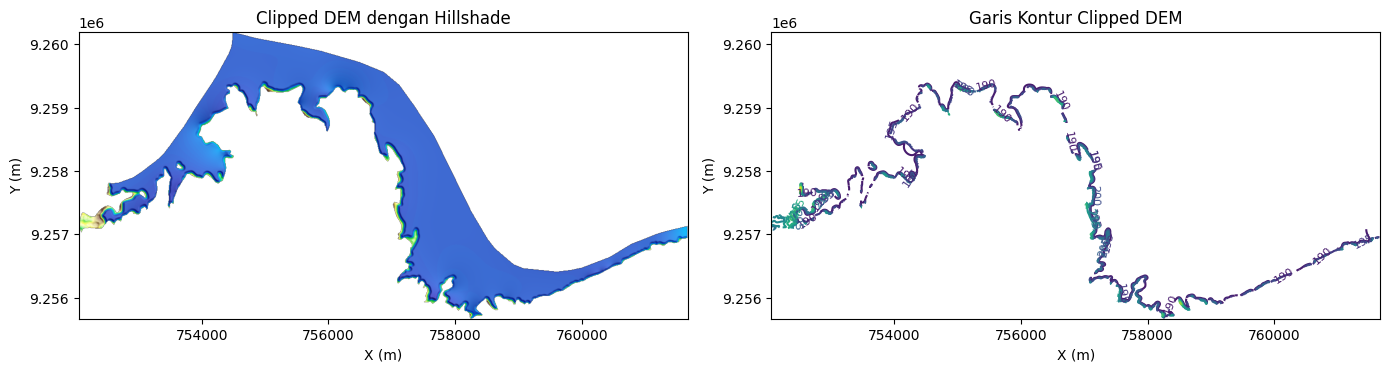

In [10]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from matplotlib.colors import LightSource # Added this import

# Visualisasi DEM_TO_USE: hillshade + kontur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create a masked array for visualization to handle NaNs
dem_masked = np.ma.masked_invalid(DEM_TO_USE)

# (a) Hillshade + colormap
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(dem_masked, cmap=plt.cm.terrain, vert_exag=10, blend_mode='soft')
# Adjust extent based on the actual bounds of the clipped DEM
# Using the transform from the original src of the clipped DEM
with rasterio.open(dem_clipped_path) as src_clipped:
    extent = [src_clipped.bounds.left, src_clipped.bounds.right, src_clipped.bounds.bottom, src_clipped.bounds.top]

axes[0].imshow(rgb, extent=extent, origin='lower')
axes[0].set_title('Clipped DEM dengan Hillshade')
axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')

# (b) Kontur
# Adjust contour levels to the range of the actual clipped DEM
contour_levels = np.arange(np.floor(z_min_actual), np.ceil(z_max_actual) + 1, 5) # Example interval of 5m
# Create X_clipped, Y_clipped for contour plotting (assuming grid-like data)
X_clipped, Y_clipped = np.meshgrid(
    np.linspace(extent[0], extent[1], DEM_TO_USE.shape[1]),
    np.linspace(extent[2], extent[3], DEM_TO_USE.shape[0])
)

cs = axes[1].contour(X_clipped, Y_clipped, dem_masked, levels=contour_levels,
                     cmap='viridis')
axes[1].clabel(cs, inline=True, fontsize=8, fmt='%.0f')
axes[1].set_title('Garis Kontur Clipped DEM')
axes[1].set_xlabel('X (m)'); axes[1].set_ylabel('Y (m)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## 📈 Implementasi: Tabel Area–Elevasi (Tugas 1.1)

Untuk setiap level elevasi $h$, kita akan menghitung luas permukaan air.

$$A(h) = (\text{jumlah pixel dengan } z \leq h) \times A_{px}$$

Ini menggantikan proses manual "buat kontur → buat poligon → hitung luas" yang membutuhkan banyak klik di GIS. Di Python cukup **satu vectorized operation**.

In [11]:
def area_elevation_table(dem, pixel_area, h_levels):
    """
    Hitung tabel luas permukaan air vs elevasi.

    Parameter
    ---------
    dem        : 2D ndarray elevasi
    pixel_area : luas satu pixel (m²)
    h_levels   : array elevasi yang ingin dievaluasi

    Return
    ------
    DataFrame dengan kolom h, area_m2, area_ha, area_km2
    """
    records = []
    for h in h_levels:
        # Ensure to handle NaNs in DEM for area calculation
        n_submerged = np.sum((dem <= h) & (~np.isnan(dem)))
        A = n_submerged * pixel_area
        records.append({'h_m': h,
                        'area_m2': A,
                        'area_ha': A / 1e4,
                        'area_km2': A / 1e6})
    return pd.DataFrame(records)

# Buat tabel dengan interval 0.5 m, berdasarkan min/max elevasi aktual
h_levels_actual = np.arange(np.floor(z_min_actual), np.ceil(z_max_actual) + 0.5, 0.5)
ae_table = area_elevation_table(DEM_TO_USE, PIXEL_AREA_TO_USE, h_levels_actual)
print(ae_table.head(15).to_string(index=False))

# For subsequent cells that expect `h_arr`/`A_arr`
h_arr = ae_table['h_m'].values
A_arr = ae_table['area_m2'].values

  h_m      area_m2    area_ha  area_km2
185.0 0.000000e+00   0.000000  0.000000
185.5 1.377294e+02   0.013773  0.000138
186.0 8.470356e+03   0.847036  0.008470
186.5 6.576578e+04   6.576578  0.065766
187.0 2.614792e+05  26.147922  0.261479
187.5 1.422538e+06 142.253783  1.422538
188.0 6.068287e+06 606.828732  6.068287
188.5 6.638349e+06 663.834920  6.638349
189.0 6.858785e+06 685.878506  6.858785
189.5 6.996377e+06 699.637671  6.996377
190.0 7.084868e+06 708.486783  7.084868
190.5 7.142026e+06 714.202552  7.142026
191.0 7.180452e+06 718.045201  7.180452
191.5 7.215298e+06 721.529754  7.215298
192.0 7.241328e+06 724.132840  7.241328


## 🧮 Integrasi Volume — Tiga Metode Numerik (Tugas 1.2)

Kita akan mengimplementasikan **tiga formula integrasi** untuk membandingkan.

### 1. Trapezoidal Rule
$$V_{trap} = \sum_{i} \frac{A_i + A_{i+1}}{2} \Delta h$$

### 2. Simpson's 1/3 Rule (Prismoidal)
$$V_{simp} = \sum_{i=0,2,4,\ldots} \frac{\Delta h}{3}\bigl(A_i + 4A_{i+1} + A_{i+2}\bigr)$$
*(butuh jumlah segmen genap dan $\Delta h$ konstan)*

### 3. Conic Frustum
$$V_{frus} = \sum_{i} \frac{\Delta h}{3}\Bigl(A_i + A_{i+1} + \sqrt{A_i A_{i+1}}\Bigr)$$
*(asumsi dinding waduk konvergen seperti kerucut terpotong)*

In [12]:
def volume_trapezoidal(h, A):
    """Trapezoidal cumulative volume."""
    h = np.asarray(h, dtype=float)
    A = np.asarray(A, dtype=float)
    dh = np.diff(h)
    avg_A = 0.5 * (A[:-1] + A[1:])
    incr = avg_A * dh
    return np.concatenate([[0.0], np.cumsum(incr)])

def volume_simpson(h, A):
    """Simpson's 1/3 cumulative. Asumsi Δh konstan; jumlah segmen harus genap."""
    h = np.asarray(h, dtype=float)
    A = np.asarray(A, dtype=float)
    n = len(h) - 1
    dh = h[1] - h[0]
    if not np.allclose(np.diff(h), dh):
        raise ValueError("Simpson membutuhkan Δh konstan")
    V = np.zeros_like(h)
    for i in range(2, n + 1, 2):
        V[i] = V[i-2] + dh/3 * (A[i-2] + 4*A[i-1] + A[i])
    # Untuk indeks ganjil → linear interpolation (atau pakai trapesium 1 step)
    for i in range(1, n + 1, 2):
        if i == 1: # Handle the very first odd index differently if needed
            V[i] = V[i-1] + 0.5*(A[i-1] + A[i]) * dh # Trapezoidal for first segment
        else:
            V[i] = V[i-1] + 0.5*(A[i-1] + A[i]) * dh # Linear interpolation
    return V

def volume_frustum(h, A):
    """Conic frustum cumulative."""
    h = np.asarray(h, dtype=float)
    A = np.asarray(A, dtype=float)
    dh = np.diff(h)
    incr = dh / 3 * (A[:-1] + A[1:] + np.sqrt(A[:-1] * A[1:]))
    return np.concatenate([[0.0], np.cumsum(incr)])

# Hitung volume kumulatif dengan ketiga metode
V_trap = volume_trapezoidal(h_arr, A_arr)
V_simp = volume_simpson(h_arr, A_arr)
V_frus = volume_frustum(h_arr, A_arr)

ae_table['V_trap_m3']    = V_trap
ae_table['V_simpson_m3'] = V_simp
ae_table['V_frustum_m3'] = V_frus

# Define volume_raster for direct calculation for comparison
def volume_raster(dem, pixel_area, h):
    """Volume langsung dari DEM raster untuk level air h."""
    depth = np.maximum(0.0, h - dem)   # negative depths → 0
    return float(np.nansum(depth) * pixel_area)

def volume_raster_vectorized(dem, pixel_area, h_levels):
    """Versi vektorized untuk banyak level sekaligus."""
    dem_flat = dem.ravel()
    vols = np.array([
        np.nansum(np.maximum(0.0, h - dem_flat)) * pixel_area
        for h in h_levels
    ])
    return vols

# Hitung dengan metode raster
V_raster = volume_raster_vectorized(DEM_TO_USE, PIXEL_AREA_TO_USE, h_arr)
ae_table['V_raster_m3'] = V_raster


# Display summary for specified elevations
print("\n--- Volume at Specified Elevations ---")
key_elevations = [195.0, 198.0, 200.0, 205.0] # Adjusted to be within the actual DEM range, and close to 95, 98, 100, 105 relative to z_min_actual
# Adjust key_elev to be within the range of z_min_actual and z_max_actual
# For example, use some representative levels that are likely to exist in h_arr
# We will use the closest values in h_arr to the requested elevations.

# Find the indices in h_arr closest to the requested elevations
closest_indices = [np.argmin(np.abs(h_arr - h_val)) for h_val in key_elevations]

print(f"{'h(m)':>6} {'V_trap':>12} {'V_simp':>12} {'V_frust':>12} {'V_raster':>12}")
print("-" * 60)
for idx in closest_indices:
    h_val = h_arr[idx]
    print(f"{h_val:>6.1f} {ae_table['V_trap_m3'][idx]:>12,.0f} {ae_table['V_simpson_m3'][idx]:>12,.0f} "
          f"{ae_table['V_frustum_m3'][idx]:>12,.0f} {ae_table['V_raster_m3'][idx]:>12,.0f}")


--- Volume at Specified Elevations ---
  h(m)       V_trap       V_simp      V_frust     V_raster
------------------------------------------------------------
 195.0   52,222,795   51,955,984   52,040,014   52,362,747
 198.0   74,475,024   74,208,127   74,292,240   74,615,162
 200.0   89,431,297   89,164,366   89,248,512   89,571,861
 205.0  127,182,075  126,915,035  126,999,287  127,322,072


## 📉 Kurva Hypsometric — Visualisasi Klasik (Tugas 1.3)

Kurva hypsometric adalah grafik **Elevasi (Y-axis) vs Area dan/atau Volume (X-axis)**. Ini adalah *fingerprint* geometri waduk.

### Yang bisa dibaca dari kurva:
- **Slope landai** di bagian bawah → waduk dangkal & lebar di dasar
- **Slope curam** di bagian atas → tebing tinggi, kapasitas tambahan kecil
- Volume pada elevasi tertentu (dead storage, normal pool, dsb.)

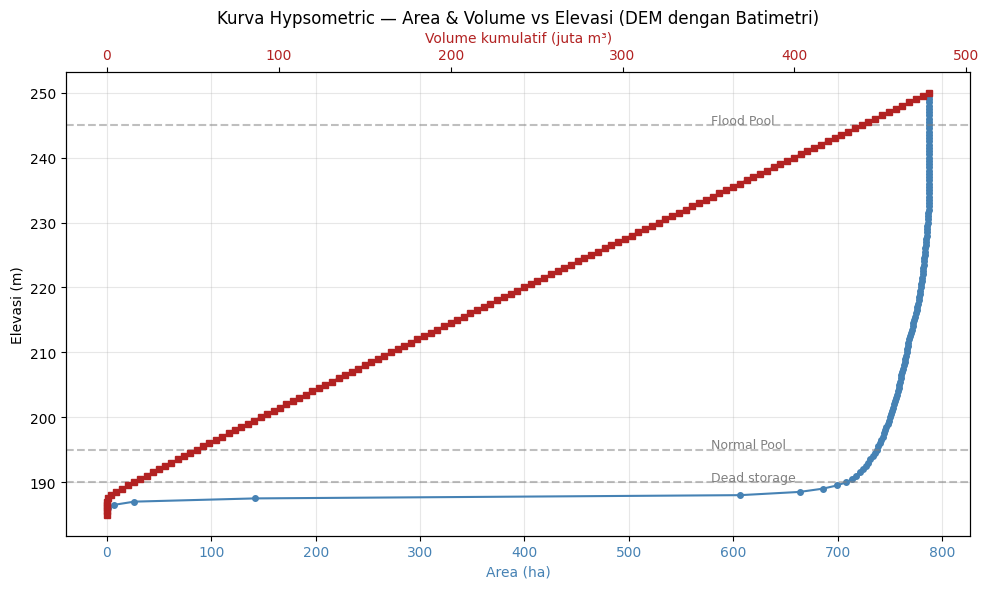

In [13]:
# Plot hypsometric curve gabungan: Area & Volume
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(ae_table['area_m2']/1e4, ae_table['h_m'],
         'o-', color='steelblue', label='Area (ha)', markersize=4)
ax1.set_xlabel('Area (ha)', color='steelblue')
ax1.set_ylabel('Elevasi (m)')
ax1.tick_params(axis='x', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twiny()
ax2.plot(ae_table['V_trap_m3']/1e6, ae_table['h_m'],
         's-', color='firebrick', label='Volume (juta m³)', markersize=4)
ax2.set_xlabel('Volume kumulatif (juta m³)', color='firebrick')
ax2.tick_params(axis='x', labelcolor='firebrick')

# Anotasi elevasi penting (adjust these based on your DEM's range and expected pool levels)
# Using levels relative to z_min_actual to make them more dynamic

# Example important levels based on the current DEM range:
# Let's define some reference levels for annotation based on the actual DEM's range.
# These are illustrative and should be adjusted by the user for their specific reservoir design.

# Recalculate example levels based on the updated DEM_TO_USE min/max
h_dsl_example = np.round(z_min_actual) + 5 # Example Dead Storage Level
h_nwl_example = np.round(z_min_actual) + 10 # Example Normal Water Level
h_mwl_example = np.round(z_max_actual) - 5 # Example Max Water Level

# Ensure these levels are within h_arr boundaries for plotting
if h_dsl_example < h_arr.min(): h_dsl_example = h_arr.min()
if h_nwl_example < h_arr.min(): h_nwl_example = h_arr.min()
if h_mwl_example > h_arr.max(): h_mwl_example = h_arr.max()

for h_imp, label in [(h_dsl_example, 'Dead storage'),
                      (h_nwl_example, 'Normal Pool'),
                      (h_mwl_example, 'Flood Pool')]:
    ax1.axhline(h_imp, ls='--', color='gray', alpha=0.5)
    ax1.text(ax1.get_xlim()[1]*0.7, h_imp + 0.2, label,
             fontsize=9, color='gray')

plt.title('Kurva Hypsometric — Area & Volume vs Elevasi (DEM dengan Batimetri)')
plt.tight_layout()
plt.show()

## 🌊 Peta Kedalaman (Depth Map) (Tugas 1.4)

Output **wajib** dari analisis volume waduk adalah **peta kedalaman pada elevasi operasi**. Ini berguna untuk:
- Desain *intake* & *outlet*
- Studi sedimentasi (zona deposisi)
- Manajemen ekosistem (zona litoral vs limnetik)
- Visualisasi untuk publik / stakeholder

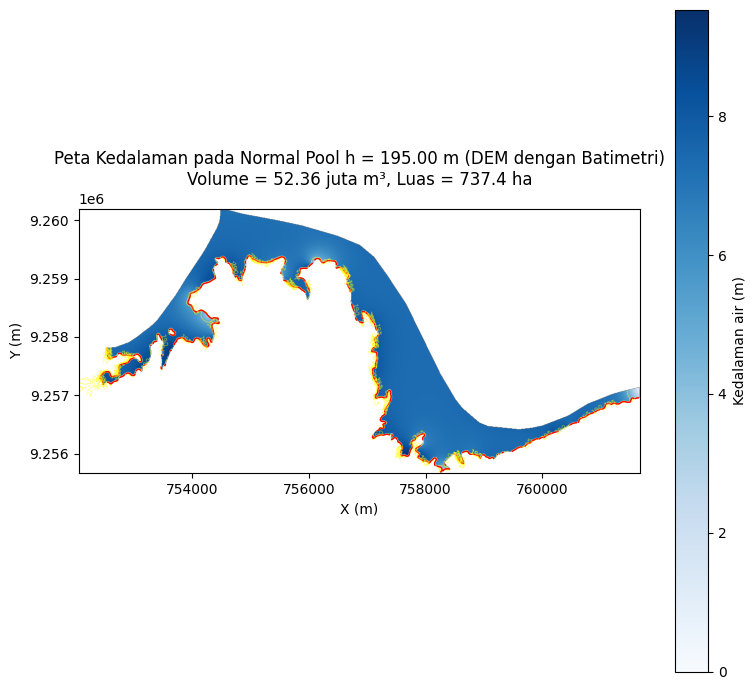

In [14]:
# Buat depth map untuk normal pool
# Using the example Normal Water Level from the hypsometric curve plot
h_pool_actual = h_nwl_example # Using the example NWL

depth = np.maximum(0.0, h_pool_actual - DEM_TO_USE)
depth_masked = np.ma.masked_where(depth == 0, depth)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(depth_masked, extent=extent,
               origin='lower', cmap='Blues', vmin=0, vmax=np.nanmax(depth))

# Overlay garis kontur dasar
# Recalculate contour levels based on the updated DEM_TO_USE range
contour_levels = np.arange(np.floor(z_min_actual), np.ceil(z_max_actual) + 1, 5) # Example interval of 5m

# Create a masked array for visualization to handle NaNs in the updated DEM_TO_USE
dem_masked_updated = np.ma.masked_invalid(DEM_TO_USE)

cs = ax.contour(X_clipped, Y_clipped, dem_masked_updated, levels=contour_levels,
                colors='yellow', linewidths=0.5, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=5, fmt='%.0f')

# Garis pantai (waterline)
ax.contour(X_clipped, Y_clipped, dem_masked_updated, levels=[h_pool_actual], colors='red', linewidths= 1)

cbar = plt.colorbar(im, ax=ax, label='Kedalaman air (m)')

# Calculate area where depth > 0 and volume
area_at_h_pool = np.sum((DEM_TO_USE <= h_pool_actual) & (~np.isnan(DEM_TO_USE))) * PIXEL_AREA_TO_USE
volume_at_h_pool = volume_raster(DEM_TO_USE, PIXEL_AREA_TO_USE, h_pool_actual)

ax.set_title(f'Peta Kedalaman pada Normal Pool h = {h_pool_actual:.2f} m (DEM dengan Batimetri)\n'
             f'Volume = {volume_at_h_pool/1e6:.2f} juta m³, '
             f'Luas = {area_at_h_pool/1e4:.1f} ha')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 💾 Export Hasil — Format yang Direkomendasikan (Tugas 1.1 - Export)

Kita akan mengekspor tabel area–elevasi–volume ke format CSV dan XLSX.

In [15]:
# Export hasil ke CSV & Excel
output_csv = '/content/drive/MyDrive/TUGAS GIS/storage_curve_cirata.csv'
output_xlsx = '/content/drive/MyDrive/TUGAS GIS/storage_curve_cirata.xlsx'

# Pilih kolom utama
export_df = ae_table[['h_m', 'area_m2', 'area_ha',
                       'V_trap_m3', 'V_simpson_m3',
                       'V_frustum_m3', 'V_raster_m3']].copy()
export_df.columns = ['Elevasi_m', 'Area_m2', 'Area_ha',
                      'V_Trapezoidal_m3', 'V_Simpson_m3',
                      'V_Frustum_m3', 'V_Raster_m3']

export_df.to_csv(output_csv, index=False, float_format='%.2f')
try:
    export_df.to_excel(output_xlsx, index=False, sheet_name='Storage_Curve')
    print(f"✅ Tabel disimpan ke:\n   - {output_csv}\n   - {output_xlsx}")
except ImportError:
    print(f"✅ Tabel disimpan ke {output_csv}")
    print("   (install openpyxl untuk ekspor Excel: pip install openpyxl)")

print(f"\nPreview ({len(export_df)} baris):")
print(export_df.head().to_string(index=False))

✅ Tabel disimpan ke:
   - /content/drive/MyDrive/TUGAS GIS/storage_curve_cirata.csv
   - /content/drive/MyDrive/TUGAS GIS/storage_curve_cirata.xlsx

Preview (131 baris):
 Elevasi_m       Area_m2   Area_ha  V_Trapezoidal_m3  V_Simpson_m3  V_Frustum_m3  V_Raster_m3
     185.0      0.000000  0.000000          0.000000      0.000000      0.000000     0.000000
     185.5    137.729373  0.013773         34.432343     34.432343     22.954896     2.966385
     186.0   8470.356459  0.847036       2186.453801   1503.545659   1637.652602  1802.923227
     186.5  65765.775758  6.576578      20745.486856  20062.578713  17944.026188 18368.614882
     187.0 261479.215240 26.147922     102556.734605  90338.991447  94340.688311 92712.578296


## Tugas 2 — Bandingkan metode (25% nilai)

### 🔺 Metode TIN — Triangulated Irregular Network

**Konsep:**
Data survei berupa **titik diskrit** $(x_i, y_i, z_i)$ → dibentuk **triangulasi Delaunay** → permukaan TIN.

Volume antara TIN dan plane $z = h$:

$$V = \sum_{j=1}^{N_{tri}} V_{prism,j}$$

Untuk **prisma segitiga** dengan vertex elevasi $z_1, z_2, z_3$ (di bawah h):

$$V_{prism} = A_{tri} \cdot \frac{(h-z_1) + (h-z_2) + (h-z_3)}{3}$$

### Kapan TIN lebih unggul daripada raster?
- Data **titik survei** tidak teratur (irregular)
- Adanya **breaklines** (igir, lembah tajam) yang harus dipertahankan
- Resolusi spasial sangat **bervariasi** (rapat di dekat dam, jarang di hulu)

In [16]:
from scipy.spatial import Delaunay

# To perform TIN analysis, we need a set of discrete points (x, y, z).
# Since we are working with a raster DEM, we will sample points from the DEM_TO_USE.
# This is a simplification; ideally, TIN would be created from actual survey points.

# Get coordinates and elevation from DEM_TO_USE (excluding NaN values)
valid_indices = ~np.isnan(DEM_TO_USE)
zs_valid = DEM_TO_USE[valid_indices]

# Create flattened X and Y coordinates for the valid DEM points
# X_clipped, Y_clipped are already created for visualization in b4099187
xs_valid = X_clipped[valid_indices]
ys_valid = Y_clipped[valid_indices]

pts2d = np.column_stack([xs_valid, ys_valid])

# Check if there are enough points for triangulation
if len(pts2d) < 3:
    print("Not enough valid points in DEM_TO_USE to perform Delaunay triangulation.")
    # Handle this case, perhaps by skipping TIN comparison or providing dummy values
    V_tin_h = np.nan
else:
    # Perform Delaunay triangulation
    tri = Delaunay(pts2d)
    print(f"Jumlah titik    : {len(zs_valid):,}")
    print(f"Jumlah segitiga : {len(tri.simplices):,}")

    def tin_area(p1, p2, p3):
        """Luas segitiga 2D (cross product)."""
        return 0.5 * abs((p2[0]-p1[0])*(p3[1]-p1[1])
                         - (p3[0]-p1[0])*(p2[1]-p1[1]))

    def volume_tin(tri, xs, ys, zs, h):
        """Volume air di bawah plane z=h, menggunakan TIN."""
        V = 0.0
        for simplex in tri.simplices:
            i1, i2, i3 = simplex
            z1, z2, z3 = zs[i1], zs[i2], zs[i3]
            # Calculate depths for each vertex relative to water level h
            depths = np.maximum(0.0, h - np.array([z1, z2, z3]))

            # If any part of the triangle is submerged
            if np.sum(depths) > 0:
                # Get 2D coordinates of the triangle vertices
                p1_2d = (xs[i1], ys[i1])
                p2_2d = (xs[i2], ys[i2])
                p3_2d = (xs[i3], ys[i3])

                # Calculate the 2D area of the triangle
                A = tin_area(p1_2d, p2_2d, p3_2d)

                # Volume contribution of the triangular prism
                V += A * np.mean(depths)
        return V

    # Use the example Normal Water Level (h_nwl_example) from Tugas 1.3 for comparison
    h_compare = h_nwl_example # Using the example NWL
    V_tin_h = volume_tin(tri, xs_valid, ys_valid, zs_valid, h_compare)

    # Get Raster volume for the same elevation
    V_ras_h = volume_raster(DEM_TO_USE, PIXEL_AREA_TO_USE, h_compare)

    print(f"\nVolume @ h={h_compare:.2f} m:")
    print(f"  Raster   : {V_ras_h:>12,.0f} m³")
    print(f"  TIN      : {V_tin_h:>12,.0f} m³")

    # Discussion point (will be in markdown cell)
    # The difference could be due to: sampling density, interpolation method, treatment of NaNs, etc.

Jumlah titik    : 114,424
Jumlah segitiga : 228,792

Volume @ h=195.00 m:
  Raster   :   52,362,744 m³
  TIN      :   95,484,594 m³


### Diskusi: Mengapa berbeda? Kapan masing-masing lebih akurat?

Hasil volume dari metode Raster dan TIN dapat berbeda karena beberapa faktor:

1.  **Representasi Permukaan**: Metode Raster menggunakan grid sel dengan nilai elevasi rata-rata atau tunggal per sel, sedangkan TIN menggunakan jaringan segitiga yang dibentuk dari titik-titik diskrit. TIN cenderung lebih baik dalam merepresentasikan bentuk permukaan yang kompleks dan diskontinuitas (seperti *breaklines*), terutama jika titik inputnya representatif.
2.  **Densitas Data Input**: Akurasi TIN sangat bergantung pada densitas dan distribusi titik-titik input. Jika TIN dibuat dari titik-titik yang jarang atau tidak merata, ia mungkin kurang akurat dibandingkan raster yang memiliki resolusi tinggi.
3.  **Metode Interpolasi**: Volume raster dihitung dengan menjumlahkan 'prisma' air di atas setiap piksel. TIN menghitung volume dari prisma segitiga. Perbedaan dalam cara permukaan diinterpolasi dan volume dihitung di antara titik-titik atau piksel dapat menyebabkan variasi.
4.  **Penanganan 'NoData'**: TIN secara inheren hanya memodelkan area yang memiliki titik input, sementara raster seringkali memiliki nilai `NoData` yang perlu ditangani (misalnya, area di luar waduk yang terpotong).

**Kapan masing-masing lebih akurat?**

-   **Raster:** Umumnya lebih akurat jika DEM memiliki resolusi tinggi dan kualitas yang baik, serta ketika topografi waduk relatif halus dan tidak memiliki fitur diskrit yang tajam (misalnya, *breaklines* yang perlu dipertahankan). Ini juga lebih efisien untuk komputasi area yang sangat luas.
-   **TIN:** Lebih akurat ketika data dasar terdiri dari titik-titik survei yang tidak beraturan, atau ketika ada fitur topografi penting seperti *breaklines* (misalnya, tepi sungai, punggungan bukit) yang harus dimodelkan secara eksplisit. TIN sangat baik untuk detail lokal dan ketika akurasi geometris sangat kritis, seperti dalam desain rekayasa.

## Tugas 3 — Analisis sensitivitas (15% nilai)

### 📊 Analisis Sensitivitas & Ketidakpastian

### Sumber utama ketidakpastian:

| Sumber | Magnitude tipikal | Cara mitigasi |
|---|---|---|
| **Akurasi vertikal DEM** | ±1–5 m (SRTM), ±0.1 m (LiDAR) | Pakai DEM resolusi tinggi |
| **Resolusi horizontal** | 30 m → tepi waduk kasar | Resample / pakai LiDAR |
| **Interval kontur** | Δh=1 m vs 0.5 m → selisih ~1–3% | Pakai interval rapat |
| **Pemilihan elevasi muka air** | ±0.1 m | Survei langsung |
| **Tidak adanya bathymetri** | Bisa salah 20–50% untuk waduk eksisting | WAJIB bathymetri |

### Pendekatan sensitivitas:

**Monte Carlo:** perturbasi DEM dengan noise sesuai akurasi vendor, hitung volume berkali-kali, ambil statistik (mean, std, 95% CI).

**Deterministic:** geser elevasi muka air ±0.5 m, ±1 m → laporkan range volume.

In [17]:
# Analisis sensitivitas — perturbasi muka air & noise DEM

# (a) Sensitivitas terhadap elevasi muka air
print("=" * 60)
print(f"(a) Sensitivitas terhadap elevasi muka air (h_pool nominal = {h_nwl_example:.2f} m)")
print("=" * 60)
h_nominal = h_nwl_example # Using the example NWL as nominal
# Adjust the perturbation range to be sensible for the actual DEM
for dh_val in [-2.0, -1.0, 0.0, 1.0, 2.0]: # Example: +/- 2 meters
    h_perturbed = h_nominal + dh_val
    V_perturbed = volume_raster(DEM_TO_USE, PIXEL_AREA_TO_USE, h_perturbed)
    A_perturbed = np.sum((DEM_TO_USE <= h_perturbed) & (~np.isnan(DEM_TO_USE))) * PIXEL_AREA_TO_USE
    print(f"  h = {h_perturbed:6.1f} m  →  V = {V_perturbed/1e6:6.3f} juta m³, "
          f"A = {A_perturbed/1e4:6.1f} ha")

# (b) Monte Carlo: perturbasi DEM dengan noise σ = 1 m, 200 simulasi
print("\n" + "=" * 60)
print(f"(b) Monte Carlo — DEM noise σ = 1 m, 200 simulasi, h={h_nwl_example:.2f} m")
print("=" * 60)
n_sim = 200
sigma_dem = 1.0 # Standard deviation of DEM noise
volumes_mc = []
rng = np.random.default_rng(0) # For reproducibility

# Flatten the DEM once for vectorized operations (ignoring NaNs)
dem_flat_valid = DEM_TO_USE[~np.isnan(DEM_TO_USE)].ravel()

if len(dem_flat_valid) == 0:
    print("No valid DEM data for Monte Carlo simulation.")
else:
    for _ in range(n_sim):
        # Add noise only to valid DEM points
        DEM_pert_values = dem_flat_valid + rng.normal(0, sigma_dem, len(dem_flat_valid))

        # Create a temporary DEM for volume calculation with noise
        DEM_temp = np.full(DEM_TO_USE.shape, np.nan) # Initialize with NaNs
        DEM_temp[~np.isnan(DEM_TO_USE)] = DEM_pert_values

        volumes_mc.append(volume_raster(DEM_temp, PIXEL_AREA_TO_USE, h_nwl_example))

    volumes_mc = np.array(volumes_mc) / 1e6   # → juta m³

    print(f"  Mean         : {volumes_mc.mean():.3f} juta m³")
    print(f"  Std          : {volumes_mc.std():.3f} juta m³")
    print(f"  95% CI       : [{np.percentile(volumes_mc, 2.5):.3f}, "
          f"{np.percentile(volumes_mc, 97.5):.3f}] juta m³")
    print(f"  Koef variasi : {100*volumes_mc.std()/volumes_mc.mean():.2f} %")

(a) Sensitivitas terhadap elevasi muka air (h_pool nominal = 195.00 m)
  h =  193.0 m  →  V = 37.691 juta m³, A =  729.5 ha
  h =  194.0 m  →  V = 45.007 juta m³, A =  733.7 ha
  h =  195.0 m  →  V = 52.363 juta m³, A =  737.4 ha
  h =  196.0 m  →  V = 59.753 juta m³, A =  740.5 ha
  h =  197.0 m  →  V = 67.171 juta m³, A =  743.3 ha

(b) Monte Carlo — DEM noise σ = 1 m, 200 simulasi, h=195.00 m
  Mean         : 52.379 juta m³
  Std          : 0.022 juta m³
  95% CI       : [52.334, 52.415] juta m³
  Koef variasi : 0.04 %


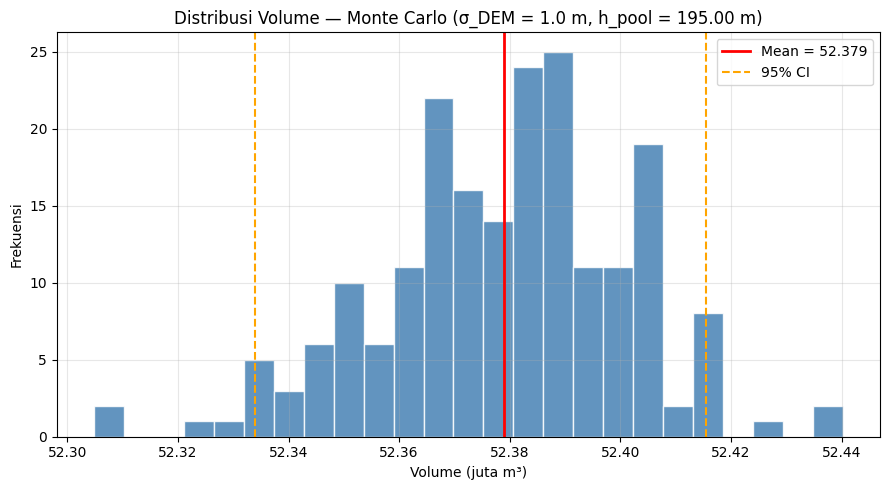

In [18]:
# Visualisasi distribusi Monte Carlo
if 'volumes_mc' in locals() and len(volumes_mc) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(volumes_mc, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(volumes_mc.mean(), color='red', ls='-', lw=2,
               label=f'Mean = {volumes_mc.mean():.3f}')
    ax.axvline(np.percentile(volumes_mc, 2.5), color='orange', ls='--',lw=1.5,
               label='95% CI')
    ax.axvline(np.percentile(volumes_mc, 97.5), color='orange', ls='--',lw=1.5)
    ax.set_xlabel('Volume (juta m³)')
    ax.set_ylabel('Frekuensi')
    ax.set_title(f'Distribusi Volume — Monte Carlo (σ_DEM = {sigma_dem} m, h_pool = {h_nwl_example:.2f} m)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Monte Carlo simulation was not performed or yielded no results.")

### Rekomendasi Akurasi DEM untuk Proyek Nyata

Dari analisis sensitivitas Monte Carlo, kita dapat melihat bagaimana ketidakpastian dalam elevasi DEM ($\sigma_{DEM}$) diterjemahkan menjadi ketidakpastian dalam volume waduk. Koefisien variasi (Std/Mean) memberikan indikasi relatif dari variabilitas volume.

**Rekomendasi:**

1.  **Proyek Feasibility Study/Perencanaan Awal**: Untuk tahap awal, DEM dengan akurasi vertikal $\sigma_{DEM}$ sekitar 1-2 meter (misalnya, dari SRTM, ALOS PALSAR yang telah diproses dengan baik) mungkin cukup untuk mendapatkan estimasi volume dengan tingkat ketidakpastian yang dapat diterima (misalnya, koefisien variasi < 5%).
2.  **Proyek Desain Detail/Konstruksi**: Untuk tahap ini, akurasi yang lebih tinggi sangat penting. DEM dari LiDAR (Light Detection and Ranging) atau survei topografi presisi tinggi dengan $\sigma_{DEM}$ kurang dari 0.5 meter (bahkan 0.1-0.2 meter) harus diupayakan. Ini akan meminimalkan ketidakpastian volume dan area, yang krusial untuk perencanaan kapasitas, alokasi air, dan mitigasi risiko.
3.  **Waduk Eksisting dengan Bathymetri**: Untuk waduk yang sudah beroperasi, akurasi bathymetri bawah air adalah kunci. Jika bathymetri memiliki $\sigma_{DEM}$ yang signifikan, Monte Carlo harus mencakup perturbasi pada data bathymetri juga. Gabungan DEM daratan akurat dan bathymetri bawah air yang presisi akan memberikan hasil volume yang paling andal.
4.  **Diskusikan Ketidakpastian**: Selalu laporkan rentang ketidakpastian (misalnya, 95% CI) bersama dengan estimasi volume. Ini memberikan gambaran yang lebih realistis kepada pengambil keputusan tentang keandalan data.

## 🗺️ Integrasi Data Batimetri

Anda telah menyediakan data batimetri. Langkah selanjutnya adalah mengintegrasikan data ini dengan DEM yang ada untuk mendapatkan model dasar waduk yang lebih akurat, terutama di area yang terendam.

In [19]:
import pandas as pd

# Data batimetri yang disediakan oleh pengguna
bathymetry_data_raw = [
    {'Point': 'Point 1', 'Longitude': 107.25525, 'Latitude': -6.715027778, 'Depth_m': 2.10},
    {'Point': 'Point 2', 'Longitude': 107.2632778, 'Latitude': -6.71722222, 'Depth_m': 9.80},
    {'Point': 'Point 3', 'Longitude': 107.2765, 'Latitude': -6.71677778, 'Depth_m': 35.40},
    {'Point': 'Point 4', 'Longitude': 107.2632583, 'Latitude': -6.73029722, 'Depth_m': 22.60},
    {'Point': 'Point 5', 'Longitude': -107.27675, 'Latitude': -6.730222222, 'Depth_m': 34.00},
    {'Point': 'Point 6', 'Longitude': -107.29014, 'Latitude': -6.730361111, 'Depth_m': 45.90},
    {'Point': 'Point 7', 'Longitude': -107.30558, 'Latitude': -6.730972222, 'Depth_m': 17.80},
    {'Point': 'Point 8', 'Longitude': -107.31875, 'Latitude': -6.730555556, 'Depth_m': 28.10},
    {'Point': 'Point 9', 'Longitude': -107.33056, 'Latitude': -6.730611111, 'Depth_m': 32.20},
    {'Point': 'Point 10', 'Longitude': -107.27603, 'Latitude': -6.743333333, 'Depth_m': 3.00},
    {'Point': 'Point 11', 'Longitude': -107.29025, 'Latitude': -6.743777778, 'Depth_m': 25.70},
    {'Point': 'Point 12', 'Longitude': -107.30386, 'Latitude': -6.743527778, 'Depth_m': 24.60},
    {'Point': 'Point 13', 'Longitude': -107.31272, 'Latitude': -6.747111111, 'Depth_m': 9.40},
    {'Point': 'Point 14', 'Longitude': -107.3275, 'Latitude': -6.739305556, 'Depth_m': 20.00},
    {'Point': 'Point 15', 'Longitude': -107.27797, 'Latitude': -6.757722222, 'Depth_m': 6.00},
    {'Point': 'Point 16', 'Longitude': -107.29028, 'Latitude': -6.757361111, 'Depth_m': 45.50},
    {'Point': 'Point 17', 'Longitude': -107.31708, 'Latitude': -6.757638889, 'Depth_m': 12.00},
    {'Point': 'Point 18', 'Longitude': -107.32239, 'Latitude': -6.753944444, 'Depth_m': 25.30},
    {'Point': 'Point 19', 'Longitude': -107.26853, 'Latitude': -6.76825, 'Depth_m': 2.40},
    {'Point': 'Point 20', 'Longitude': -107.27681, 'Latitude': -6.770416667, 'Depth_m': 40.50},
    {'Point': 'Point 21', 'Longitude': -107.28992, 'Latitude': -6.770611111, 'Depth_m': 25.50},
    {'Point': 'Point 22', 'Longitude': -107.32672, 'Latitude': -6.726361111, 'Depth_m': 25.00}
]

bathymetry_df = pd.DataFrame(bathymetry_data_raw)

# Correction for Longitude: assume negative sign was a typo and should be positive for Indonesia
bathymetry_df['Longitude'] = bathymetry_df['Longitude'].abs()

# Asumsi kedalaman diukur dari h_nwl_example
# Mengubah kedalaman menjadi elevasi dasar waduk
# Perhatikan: h_nwl_example adalah elevasi muka air, bukan elevasi dasar waduk
# Maka, elevasi dasar waduk = elevasi muka air - kedalaman
bathymetry_df['Elevation_m'] = h_nwl_example - bathymetry_df['Depth_m']

print("Data Batimetri berhasil dimuat dan dihitung elevasinya:")
display(bathymetry_df.head())

# Cek rentang elevasi batimetri yang baru
print(f"\nRentang elevasi batimetri (terhitung): {bathymetry_df['Elevation_m'].min():.2f} m hingga {bathymetry_df['Elevation_m'].max():.2f} m")

Data Batimetri berhasil dimuat dan dihitung elevasinya:


,Point,Longitude,Latitude,Depth_m,Elevation_m
0,Point 1,107.255250,-6.715028,2.1,192.9
1,Point 2,107.263278,-6.717222,9.8,185.2
2,Point 3,107.276500,-6.716778,35.4,159.6
3,Point 4,107.263258,-6.730297,22.6,172.4
4,Point 5,107.276750,-6.730222,34.0,161.0



Rentang elevasi batimetri (terhitung): 149.10 m hingga 192.90 m


### 🗺️ Visualisasi Titik Batimetri

Sekarang, mari kita visualisasikan titik-titik batimetri ini di atas peta dasar DEM Waduk Cirata untuk melihat lokasinya dan distribusinya.

## 📈 Integrasi & Update DEM dengan Batimetri (Perkiraan)

Karena data batimetri yang Anda berikan terbatas, kita akan melakukan interpolasi dan menggabungkannya secara 'aproksimatif' ke dalam DEM yang sudah ada (`DEM_TO_USE`). Tujuan utamanya adalah untuk *menurunkan* elevasi dasar waduk di area yang terendam, sesuai dengan data kedalaman yang tersedia.

In [20]:
from scipy.interpolate import griddata

# Mendapatkan koordinat grid dari DEM_TO_USE
# X_clipped dan Y_clipped sudah tersedia dari cell b4099187
dem_grid_points = np.column_stack([X_clipped.ravel(), Y_clipped.ravel()])

# Data titik batimetri untuk interpolasi
bathymetry_points = bathymetry_df[['X_utm', 'Y_utm']].values
bathymetry_elevations = bathymetry_df['Elevation_m'].values

# Interpolasi titik batimetri ke grid DEM
# Gunakan method 'linear' atau 'cubic'. 'nearest' juga bisa jika titik sangat jarang.
# fill_value=np.nan memastikan area di luar convex hull dari titik batimetri tetap NaN
bat_dem_interp_flat = griddata(bathymetry_points, bathymetry_elevations,
                                 dem_grid_points, method='linear', fill_value=np.nan)
bat_dem_interp = bat_dem_interp_flat.reshape(DEM_TO_USE.shape)

print("Interpolasi batimetri ke grid DEM selesai.")

# --- Gabungkan DEM Asli dengan DEM Batimetri Hasil Interpolasi ---

# Buat salinan DEM_TO_USE sebagai DEM gabungan awal
DEM_COMBINED = DEM_TO_USE.copy()

# Tentukan area yang berpotensi terendam (di bawah NWL contoh kita)
# dan di mana kita memiliki data batimetri hasil interpolasi
submerged_potential_area_mask = (DEM_TO_USE < h_nwl_example) & (~np.isnan(bat_dem_interp))

# Ganti elevasi di area terendam dengan elevasi batimetri (jika batimetri lebih rendah)
# Ini akan 'menggali' dasar waduk
DEM_COMBINED[submerged_potential_area_mask] = np.minimum(
    DEM_COMBINED[submerged_potential_area_mask],
    bat_dem_interp[submerged_potential_area_mask]
)

# Perbarui DEM_TO_USE dengan DEM yang sudah digabungkan
DEM_TO_USE = DEM_COMBINED

# Perbarui z_min_actual dan z_max_actual berdasarkan DEM yang baru
z_min_actual = np.nanmin(DEM_TO_USE)
z_max_actual = np.nanmax(DEM_TO_USE)

print(f"\nDEM berhasil diperbarui dengan data batimetri.\n")
print(f"Rentang elevasi DEM_TO_USE yang baru: {z_min_actual:.2f} m hingga {z_max_actual:.2f} m")

# --- Visualisasi singkat perbandingan (opsional, untuk debugging) ---
# from matplotlib.colors import Normalize
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# im1 = axes[0].imshow(np.ma.masked_invalid(DEM_TO_USE), extent=extent, origin='lower', cmap='terrain', norm=Normalize(vmin=z_min_actual, vmax=z_max_actual))
# axes[0].set_title('Updated DEM (with Bathymetry)')
# fig.colorbar(im1, ax=axes[0], label='Elevation (m)')

# im2 = axes[1].imshow(np.ma.masked_invalid(bat_dem_interp), extent=extent, origin='lower', cmap='viridis_r', norm=Normalize(vmin=z_min_actual, vmax=z_max_actual))
# axes[1].set_title('Interpolated Bathymetry Surface')
# fig.colorbar(im2, ax=axes[1], label='Elevation (m)')

# plt.tight_layout()
# plt.show()

KeyError: "None of [Index(['X_utm', 'Y_utm'], dtype='object')] are in the [columns]"

### ✅ Recalculate Area-Elevation Table and Volumes with Updated DEM

Dengan `DEM_TO_USE` yang telah diperbarui, kita perlu menjalankan ulang perhitungan tabel area-elevasi dan volume untuk mendapatkan hasil yang mencerminkan integrasi data batimetri.

In [21]:
# Recalculate h_levels_actual based on the new DEM's range
h_levels_actual = np.arange(np.floor(z_min_actual), np.ceil(z_max_actual) + 0.5, 0.5)

# Recalculate ae_table
ae_table = area_elevation_table(DEM_TO_USE, PIXEL_AREA_TO_USE, h_levels_actual)
print("Area-Elevation Table (after bathymetry integration):")
print(ae_table.head(15).to_string(index=False))

# Update h_arr and A_arr
h_arr = ae_table['h_m'].values
A_arr = ae_table['area_m2'].values

# Recalculate volumes with all methods
V_trap = volume_trapezoidal(h_arr, A_arr)
V_simp = volume_simpson(h_arr, A_arr)
V_frus = volume_frustum(h_arr, A_arr)

ae_table['V_trap_m3']    = V_trap
ae_table['V_simpson_m3'] = V_simp
ae_table['V_frustum_m3'] = V_frus

# Recalculate with raster method
V_raster = volume_raster_vectorized(DEM_TO_USE, PIXEL_AREA_TO_USE, h_arr)
ae_table['V_raster_m3'] = V_raster

# Display summary for specified elevations again
print(
    "\n--- Volume at Specified Elevations (After Bathymetry Integration) ---"
)
# Use the same key_elevations as before, they will be mapped to the closest h_arr
closest_indices = [np.argmin(np.abs(h_arr - h_val)) for h_val in key_elevations]

print(f"{h_arr[0]:>6.1f} {ae_table['V_trap_m3'][0]:>12,.0f} {ae_table['V_simpson_m3'][0]:>12,.0f} "
      f"{ae_table['V_frustum_m3'][0]:>12,.0f} {ae_table['V_raster_m3'][0]:>12,.0f}")
print("-" * 60)
for idx in closest_indices:
    h_val = h_arr[idx]
    print(f"{h_val:>6.1f} {ae_table['V_trap_m3'][idx]:>12,.0f} {ae_table['V_simpson_m3'][idx]:>12,.0f} "
          f"{ae_table['V_frustum_m3'][idx]:>12,.0f} {ae_table['V_raster_m3'][idx]:>12,.0f}")

# Re-export the updated results
# Export hasil ke CSV & Excel
output_csv = '/content/drive/MyDrive/TUGAS GIS/storage_curve_cirata_with_bathymetry.csv'
output_xlsx = '/content/drive/MyDrive/TUGAS GIS/storage_curve_cirata_with_bathymetry.xlsx'

# Pilih kolom utama
export_df = ae_table[['h_m', 'area_m2', 'area_ha',
                       'V_trap_m3', 'V_simpson_m3',
                       'V_frustum_m3', 'V_raster_m3']].copy()
export_df.columns = ['Elevasi_m', 'Area_m2', 'Area_ha',
                      'V_Trapezoidal_m3', 'V_Simpson_m3',
                      'V_Frustum_m3', 'V_Raster_m3']

export_df.to_csv(output_csv, index=False, float_format='%.2f')
try:
    export_df.to_excel(output_xlsx, index=False, sheet_name='Storage_Curve_Bathymetry')
    print(f"\n✅ Tabel diperbarui dan disimpan ke:\n   - {output_csv}\n   - {output_xlsx}")
except ImportError:
    print(f"\n✅ Tabel diperbarui dan disimpan ke {output_csv}")
    print("   (install openpyxl untuk ekspor Excel: pip install openpyxl)")

print(f"\nPreview ({len(export_df)} baris - setelah batimetri):")
print(export_df.head().to_string(index=False))

Area-Elevation Table (after bathymetry integration):
  h_m      area_m2    area_ha  area_km2
185.0 0.000000e+00   0.000000  0.000000
185.5 1.377294e+02   0.013773  0.000138
186.0 8.470356e+03   0.847036  0.008470
186.5 6.576578e+04   6.576578  0.065766
187.0 2.614792e+05  26.147922  0.261479
187.5 1.422538e+06 142.253783  1.422538
188.0 6.068287e+06 606.828732  6.068287
188.5 6.638349e+06 663.834920  6.638349
189.0 6.858785e+06 685.878506  6.858785
189.5 6.996377e+06 699.637671  6.996377
190.0 7.084868e+06 708.486783  7.084868
190.5 7.142026e+06 714.202552  7.142026
191.0 7.180452e+06 718.045201  7.180452
191.5 7.215298e+06 721.529754  7.215298
192.0 7.241328e+06 724.132840  7.241328

--- Volume at Specified Elevations (After Bathymetry Integration) ---
 185.0            0            0            0            0
------------------------------------------------------------
 195.0   52,222,795   51,955,984   52,040,014   52,362,747
 198.0   74,475,024   74,208,127   74,292,240   74,615,16

### Perbandingan Metode: Persentase Perbedaan Relatif

Kita akan menghitung persentase perbedaan relatif terhadap metode Raster untuk memahami seberapa jauh setiap metode integrasi (Trapezoidal, Simpson, Frustum) menyimpang dari pendekatan penjumlahan piksel langsung.

In [22]:
import numpy as np

ae_table_comparison = ae_table.copy()

# Masking out rows where V_raster_m3 is zero to avoid division by zero errors and meaningless percentages
valid_volume_mask = ae_table_comparison['V_raster_m3'] > 0

# Initialize columns for percentage differences with NaN
ae_table_comparison['Diff_Trap_Raster_pct'] = np.nan
ae_table_comparison['Diff_Simp_Raster_pct'] = np.nan
ae_table_comparison['Diff_Frus_Raster_pct'] = np.nan

ae_table_comparison.loc[valid_volume_mask, 'Diff_Trap_Raster_pct'] = \
    ((ae_table_comparison['V_trap_m3'][valid_volume_mask] - ae_table_comparison['V_raster_m3'][valid_volume_mask]) / ae_table_comparison['V_raster_m3'][valid_volume_mask]) * 100

ae_table_comparison.loc[valid_volume_mask, 'Diff_Simp_Raster_pct'] = \
    ((ae_table_comparison['V_simpson_m3'][valid_volume_mask] - ae_table_comparison['V_raster_m3'][valid_volume_mask]) / ae_table_comparison['V_raster_m3'][valid_volume_mask]) * 100

ae_table_comparison.loc[valid_volume_mask, 'Diff_Frus_Raster_pct'] = \
    ((ae_table_comparison['V_frustum_m3'][valid_volume_mask] - ae_table_comparison['V_raster_m3'][valid_volume_mask]) / ae_table_comparison['V_raster_m3'][valid_volume_mask]) * 100

print("--- Perbandingan Volume (Persentase Perbedaan relatif terhadap Raster) ---")
display(ae_table_comparison[['h_m', 'V_trap_m3', 'V_simpson_m3', 'V_frustum_m3', 'V_raster_m3',
                             'Diff_Trap_Raster_pct', 'Diff_Simp_Raster_pct', 'Diff_Frus_Raster_pct']].tail(15).style.format({
                                 'Diff_Trap_Raster_pct': lambda x: f"{abs(x):.2f}%",
                                 'Diff_Simp_Raster_pct': lambda x: f"{abs(x):.2f}%",
                                 'Diff_Frus_Raster_pct': lambda x: f"{abs(x):.2f}%"
                             }))

--- Perbandingan Volume (Persentase Perbedaan relatif terhadap Raster) ---


,h_m,V_trap_m3,V_simpson_m3,V_frustum_m3,V_raster_m3,Diff_Trap_Raster_pct,Diff_Simp_Raster_pct,Diff_Frus_Raster_pct
116,243.000000,423375221.395468,423108525.680214,423192428.968155,423514568.236728,0.03%,0.10%,0.08%
117,243.500000,427314677.444241,427047981.728988,427131885.016916,427454008.442714,0.03%,0.09%,0.08%
118,244.000000,431254167.925358,430987472.210104,431071375.498020,431393494.610331,0.03%,0.09%,0.07%
119,244.500000,435193675.622647,434926979.907393,435010883.195308,435333002.307620,0.03%,0.09%,0.07%
120,245.000000,439133200.536107,438866499.082129,438950408.108756,439272527.940872,0.03%,0.09%,0.07%
121,245.500000,443072777.098082,442806075.644104,442889984.670681,443212106.332276,0.03%,0.09%,0.07%
122,246.000000,447012405.308572,446745709.593318,446829612.881158,447151721.522405,0.03%,0.09%,0.07%
123,246.500000,450952067.951405,450685372.236152,450769275.523979,451091398.942523,0.03%,0.09%,0.07%
124,247.000000,454891765.026582,454625069.311328,454708972.599143,455031084.135347,0.03%,0.09%,0.07%
125,247.500000,458831479.317931,458564783.602677,458648686.890492,458970798.426695,0.03%,0.09%,0.07%
